# 04. IID Federated Learning Baseline (FedAvg on 10 Clients)

**Research Paper:** *Robust Federated Learning-Based Intrusion Detection for Heterogeneous Vehicular CAN Networks*  
**Benchmark Milestone:** Phase 2A — Federated Baseline under Independent and Identically Distributed (IID) Traffic  
**Algorithm:** Federated Averaging (FedAvg, McMahan et al., 2017)  
**Model:** Lightweight 1D-CNN with GroupNorm (`CAN1DCNN`, ~40,610 parameters)  

---

## 📚 Educational Primer: Understanding Federated Learning for Connected Vehicles

### 1. What is Federated Learning (FL)?
Traditionally, deep learning intrusion detectors require uploading all raw telemetry from every vehicle into a central cloud server. In modern vehicular fleets, this is impractical:
- **Bandwidth Bottleneck:** Modern connected vehicles produce gigabytes of CAN and sensor traffic daily.
- **Privacy & Telemetry Exposure:** Raw logs reveal private driving habits, physical routes, and ECU operational states.

**Federated Learning** decouples model training from direct data collection. Instead of sending raw CAN messages to the server, **each vehicle (or ECU) trains locally** on its own data, and only shares mathematical parameter updates (weights and biases). A central server combines these updates into an improved **global model** and broadcasts it back.

### 2. What is a "Client" in this Simulation?
In this benchmark, each "client" represents a simulated vehicular ECU or connected vehicle in a fleet. We instantiate **10 simulated clients**. Each client possesses an isolated local dataset and its own instance of `CAN1DCNN`. It never sees any other client's data.

### 3. What Does "IID" Mean?
**IID** stands for *Independent and Identically Distributed*:
- **Identically Distributed:** Every client's local dataset has approximately the same balance of normal traffic (~60.9%) and cyber-attacks (~39.1%).
- **Independent:** Each client's data samples are mutually exclusive subsets of the overall training pool.

This IID benchmark establishes the **ideal collaborative performance ceiling** before we introduce fleet heterogeneity (Non-IID distributions) and Byzantine attacks in subsequent phases.

### 4. How Does Federated Averaging (FedAvg) Work?
In each communication round $t$:
1. **Broadcast:** The server sends the current global model parameters $\theta_t$ to all 10 clients.
2. **Local Training:** Each client initializes its local network with $\theta_t$ and trains for $E=1$ local epoch using its local data.
3. **Upload:** Clients send their updated weights $\theta_t^k$ and local sample count $n_k$ back to the server.
4. **Weighted Aggregation:** The server computes the new global model as a sample-weighted average:
$$\theta_{t+1} = \sum_{k=1}^{K} \frac{n_k}{N} \theta_t^k, \quad \text{where } N = \sum_{k=1}^{K} n_k$$
5. **Validation:** The server evaluates $\theta_{t+1}$ on the global held-out validation set to track generalization.


In [1]:
# Environment Setup, Reproducibility & Imports
import os
import sys
import time
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

import torch
import torch.nn as nn

# Project Root Resolution
PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.cnn1d import CAN1DCNN, count_parameters
from src.evaluation.metrics import compute_classification_metrics, plot_training_curves, plot_confusion_matrix
from src.federated import (
    create_iid_client_datasets,
    FederatedClient,
    FederatedServer,
    calculate_round_communication_bytes,
)

# Deterministic Style and Seed
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cpu")
print(f"Project root: {PROJECT_ROOT}")
print(f"Execution device: {DEVICE} (Deterministic CPU Evaluation)")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_MODELS = PROJECT_ROOT / "results" / "models"
RESULTS_METRICS = PROJECT_ROOT / "results" / "metrics"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"
RESULTS_REPORTS = PROJECT_ROOT / "results" / "reports"

for d in [RESULTS_MODELS, RESULTS_METRICS, RESULTS_FIGURES, RESULTS_REPORTS]:
    d.mkdir(parents=True, exist_ok=True)


Project root: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS
Execution device: cpu (Deterministic CPU Evaluation)


In [2]:
# 1. Load Preprocessed Benchmark Dataset
dataset_path = DATA_PROCESSED / "can_ids_processed_dataset.npz"
if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset not found at {dataset_path}. Run notebook 02 first.")

data = np.load(dataset_path, allow_pickle=True)
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
y_types_train = data["y_types_train"]
y_types_test = data["y_types_test"]

print("=== Benchmark Dataset Loaded ===")
print(f"  Training Pool:   X={X_train.shape}, y={y_train.shape} (Attack: {int(y_train.sum()):,}, Normal: {len(y_train)-int(y_train.sum()):,})")
print(f"  Global Val Set:  X={X_val.shape},   y={y_val.shape}   (Attack: {int(y_val.sum()):,}, Normal: {len(y_val)-int(y_val.sum()):,})")
print(f"  Global Test Set: X={X_test.shape},  y={y_test.shape}  (Attack: {int(y_test.sum()):,}, Normal: {len(y_test)-int(y_test.sum()):,})")


=== Benchmark Dataset Loaded ===
  Training Pool:   X=(21875, 16, 11), y=(21875,) (Attack: 8,553, Normal: 13,322)
  Global Val Set:  X=(4685, 16, 11),   y=(4685,)   (Attack: 1,798, Normal: 2,887)
  Global Test Set: X=(4690, 16, 11),  y=(4690,)  (Attack: 1,790, Normal: 2,900)


In [3]:
# 2. IID Stratified Partitioning across 10 Simulated Vehicular Clients
NUM_CLIENTS = 10

client_datasets, partition_summary = create_iid_client_datasets(
    X_train=X_train,
    y_train=y_train,
    y_types_train=y_types_train,
    num_clients=NUM_CLIENTS,
    seed=SEED,
)

# Build diagnostics table
client_rows = []
for c_info in partition_summary["clients"]:
    client_rows.append({
        "Client ID": f"Client {c_info['client_id']}",
        "Total Windows": c_info["num_samples"],
        "Normal (0)": c_info["num_normal"],
        "Attack (1)": c_info["num_attack"],
        "Attack Ratio (%)": f"{c_info['attack_ratio']*100:.2f}%",
    })

client_df = pd.DataFrame(client_rows)
print("=== IID Client Partition Summary ===")
display(client_df)

# Verify integrity: zero duplicate samples, completeness
all_assigned = sum(c["num_samples"] for c in partition_summary["clients"])
assert all_assigned == len(y_train), f"Sample mismatch: {all_assigned} vs {len(y_train)}"
print(f"\nIntegrity Verified: Exactly {all_assigned:,} samples assigned across {NUM_CLIENTS} clients with zero overlap.")


=== IID Client Partition Summary ===


,Client ID,Total Windows,Normal (0),Attack (1),Attack Ratio (%)
0,Client 0,2189,1333,856,39.10%
1,Client 1,2189,1333,856,39.10%
2,Client 2,2188,1332,856,39.12%
3,Client 3,2187,1332,855,39.09%
4,Client 4,2187,1332,855,39.09%
5,Client 5,2187,1332,855,39.09%
6,Client 6,2187,1332,855,39.09%
7,Client 7,2187,1332,855,39.09%
8,Client 8,2187,1332,855,39.09%
9,Client 9,2187,1332,855,39.09%



Integrity Verified: Exactly 21,875 samples assigned across 10 clients with zero overlap.


In [4]:
# 3. Initialize Federated Server and Client Orchestrator
CONFIG_PATH = PROJECT_ROOT / "configs" / "federated_iid_config.json"
with open(CONFIG_PATH, "r") as f:
    fed_config = json.load(f)

print("=== Experiment Configuration ===")
print(json.dumps(fed_config, indent=2))

# Initialize Global Server with centralized validation and test data
server = FederatedServer(
    val_data=(X_val, y_val),
    test_data=(X_test, y_test),
    model_config=fed_config["model"],
    eval_batch_size=fed_config["client"]["batch_size"],
    seed=SEED,
    device=DEVICE,
)

# Initialize 10 Federated Clients
clients = [
    FederatedClient(
        client_id=cd["client_id"],
        X=cd["X"],
        y=cd["y"],
        model_config=fed_config["model"],
        batch_size=fed_config["client"]["batch_size"],
        lr=fed_config["client"]["learning_rate"],
        weight_decay=fed_config["client"]["weight_decay"],
        device=DEVICE,
    )
    for cd in client_datasets
]
server.register_clients(clients)

param_info = count_parameters(server.global_model)
comm_info = calculate_round_communication_bytes(server.get_global_parameters(), num_participating_clients=NUM_CLIENTS)

print("\n=== Model & Communication Footprint ===")
print(f"  Trainable Parameters:        {param_info['trainable_parameters']:,}")
print(f"  Model State Dict Size:       {comm_info['model_size_kb']} KB ({comm_info['model_size_bytes']:,} bytes)")
print(f"  Estimated Round Comm (10 Cl): {comm_info['total_round_kb']} KB ({comm_info['total_round_mb']} MB per round)")


=== Experiment Configuration ===
{
  "experiment_name": "federated_iid_fedavg",
  "seed": 42,
  "federated": {
    "num_clients": 10,
    "distribution": "IID",
    "aggregation": "FedAvg",
    "rounds": 10,
    "local_epochs": 1
  },
  "client": {
    "batch_size": 128,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss"
  },
  "model": {
    "architecture": "CAN1DCNN",
    "in_channels": 11,
    "seq_length": 16,
    "num_classes": 2,
    "conv_channels": [
      32,
      64,
      128
    ],
    "norm_type": "GroupNorm",
    "num_groups": 4,
    "fc_hidden": 64,
    "dropout": 0.2
  },
  "data": {
    "processed_path": "data/processed/can_ids_processed_dataset.npz",
    "splits_dir": "data/splits"
  },
  "evaluation": {
    "checkpoint_metric": "val_f1",
    "device": "cpu"
  }
}

=== Model & Communication Footprint ===
  Trainable Parameters:        40,610
  Model State Dict Size:       158.63 KB (162,440.0 bytes)
  Estim

In [5]:
# 4. Run 10-Round Federated Training Loop (FedAvg)
NUM_ROUNDS = fed_config["federated"]["rounds"]
LOCAL_EPOCHS = fed_config["federated"]["local_epochs"]

training_results = server.fit(
    num_rounds=NUM_ROUNDS,
    local_epochs=LOCAL_EPOCHS,
    verbose=True,
)

best_round = training_results["best_round"]
best_val_f1 = training_results["best_val_f1"]
total_time = training_results["total_duration_seconds"]

print(f"\nFederated Training Execution Summary:")
print(f"  Total Wall-Clock Time:  {total_time:.2f} seconds")
print(f"  Average Round Time:     {total_time / NUM_ROUNDS:.2f} seconds/round")
print(f"  Selected Best Checkpoint: Round {best_round} with Validation F1: {best_val_f1 * 100:.2f}%")


STARTING FEDERATED TRAINING: 10 Rounds, 10 Clients (IID FedAvg)
Device: cpu | Local Epochs/Round: 1 | Seed: 42


Round [ 1/10] | Train Loss: 0.6051 | Val Loss: 0.3946 | Val F1: 0.8442 | Val Acc: 89.58% | Time: 6.94s


Round [ 2/10] | Train Loss: 0.3487 | Val Loss: 0.1597 | Val F1: 0.9463 | Val Acc: 95.92% | Time: 3.10s


Round [ 3/10] | Train Loss: 0.2123 | Val Loss: 0.0998 | Val F1: 0.9630 | Val Acc: 97.25% | Time: 3.67s


Round [ 4/10] | Train Loss: 0.2875 | Val Loss: 0.1278 | Val F1: 0.9380 | Val Acc: 95.52% | Time: 3.63s


...

Round [ 6/10] | Train Loss: 0.1989 | Val Loss: 0.0941 | Val F1: 0.9592 | Val Acc: 96.99% | Time: 3.04s


Round [ 7/10] | Train Loss: 0.1540 | Val Loss: 0.0689 | Val F1: 0.9741 | Val Acc: 98.06% | Time: 2.83s


Round [ 8/10] | Train Loss: 0.1401 | Val Loss: 0.0623 | Val F1: 0.9761 | Val Acc: 98.21% | Time: 2.86s


Round [ 9/10] | Train Loss: 0.1133 | Val Loss: 0.0548 | Val F1: 0.9799 | Val Acc: 98.48% | Time: 2.93s


Round [10/10] | Train Loss: 0.1100 | Val Loss: 0.0578 | Val F1: 0.9779 | Val Acc: 98.34% | Time: 3.18s
FEDERATED TRAINING COMPLETE in 35.45s
Selected Best Checkpoint: Round 9 (Val F1: 97.99%)

Federated Training Execution Summary:
  Total Wall-Clock Time:  35.45 seconds
  Average Round Time:     3.55 seconds/round
  Selected Best Checkpoint: Round 9 with Validation F1: 97.99%


In [6]:
# 5. Untouched Test Set Evaluation (Using Best Checkpoint)
test_metrics = server.evaluate_test()

print("=" * 65)
print("        FEDERATED IID BASELINE (FedAvg) TEST EVALUATION")
print("=" * 65)
print(f"Selected Best Round:       Round {best_round}")
print(f"Validation F1 at Best Rd:  {best_val_f1 * 100:.2f}%")
print(f"Test Accuracy:             {test_metrics['accuracy'] * 100:.2f}%")
print(f"Test Precision:            {test_metrics['precision'] * 100:.2f}%")
print(f"Test Recall (Sensitivity): {test_metrics['recall'] * 100:.2f}%")
print(f"Test F1-Score:             {test_metrics['f1_score'] * 100:.2f}%")
print(f"False Positive Rate (FPR): {test_metrics['false_positive_rate'] * 100:.4f}% ({test_metrics['false_positives']} / {test_metrics['false_positives'] + test_metrics['true_negatives']})")
print(f"False Negative Rate (FNR): {test_metrics['false_negative_rate'] * 100:.4f}% ({test_metrics['false_negatives']} / {test_metrics['false_negatives'] + test_metrics['true_positives']})")
if test_metrics.get("roc_auc"):
    print(f"Test ROC-AUC:              {test_metrics['roc_auc']:.4f}")
print("=" * 65)

# Format Classification Report
cm = test_metrics["confusion_matrix"]
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
print(f"\nConfusion Matrix Counts:")
print(f"  True Negatives (TN):  {tn:,}")
print(f"  False Positives (FP): {fp:,}")
print(f"  False Negatives (FN): {fn:,}")
print(f"  True Positives (TP):  {tp:,}")


        FEDERATED IID BASELINE (FedAvg) TEST EVALUATION
Selected Best Round:       Round 9
Validation F1 at Best Rd:  97.99%
Test Accuracy:             98.25%
Test Precision:            99.71%
Test Recall (Sensitivity): 95.70%
Test F1-Score:             97.66%
False Positive Rate (FPR): 0.1724% (5 / 2900)
False Negative Rate (FNR): 4.3017% (77 / 1790)
Test ROC-AUC:              0.9965

Confusion Matrix Counts:
  True Negatives (TN):  2,895
  False Positives (FP): 5
  False Negatives (FN): 77
  True Positives (TP):  1,713


In [7]:
# 6. Direct Comparison: Centralized Baseline vs Federated IID FedAvg
CENTRALIZED_JSON = RESULTS_METRICS / "centralized_baseline_v2.json"
with open(CENTRALIZED_JSON, "r") as f:
    cent_data = json.load(f)
cent_metrics = cent_data["test_metrics"]

comparison_rows = [
    {
        "Metric": "Accuracy (%)",
        "Centralized 1D-CNN": f"{cent_metrics['accuracy']*100:.2f}%",
        "Federated IID FedAvg": f"{test_metrics['accuracy']*100:.2f}%",
        "Delta": f"{(test_metrics['accuracy'] - cent_metrics['accuracy'])*100:+.2f}%",
    },
    {
        "Metric": "Precision (%)",
        "Centralized 1D-CNN": f"{cent_metrics['precision']*100:.2f}%",
        "Federated IID FedAvg": f"{test_metrics['precision']*100:.2f}%",
        "Delta": f"{(test_metrics['precision'] - cent_metrics['precision'])*100:+.2f}%",
    },
    {
        "Metric": "Recall (%)",
        "Centralized 1D-CNN": f"{cent_metrics['recall']*100:.2f}%",
        "Federated IID FedAvg": f"{test_metrics['recall']*100:.2f}%",
        "Delta": f"{(test_metrics['recall'] - cent_metrics['recall'])*100:+.2f}%",
    },
    {
        "Metric": "F1-Score (%)",
        "Centralized 1D-CNN": f"{cent_metrics['f1_score']*100:.2f}%",
        "Federated IID FedAvg": f"{test_metrics['f1_score']*100:.2f}%",
        "Delta": f"{(test_metrics['f1_score'] - cent_metrics['f1_score'])*100:+.2f}%",
    },
    {
        "Metric": "False Positive Rate (FPR)",
        "Centralized 1D-CNN": f"{cent_metrics['false_positive_rate']*100:.4f}%",
        "Federated IID FedAvg": f"{test_metrics['false_positive_rate']*100:.4f}%",
        "Delta": f"{(test_metrics['false_positive_rate'] - cent_metrics['false_positive_rate'])*100:+.4f}%",
    },
    {
        "Metric": "False Negative Rate (FNR)",
        "Centralized 1D-CNN": f"{cent_metrics['false_negative_rate']*100:.4f}%",
        "Federated IID FedAvg": f"{test_metrics['false_negative_rate']*100:.4f}%",
        "Delta": f"{(test_metrics['false_negative_rate'] - cent_metrics['false_negative_rate'])*100:+.4f}%",
    },
    {
        "Metric": "ROC-AUC",
        "Centralized 1D-CNN": f"{cent_metrics['roc_auc']:.4f}",
        "Federated IID FedAvg": f"{test_metrics['roc_auc']:.4f}",
        "Delta": f"{test_metrics['roc_auc'] - cent_metrics['roc_auc']:+.4f}",
    },
    {
        "Metric": "Training Budget",
        "Centralized 1D-CNN": "10 Central Epochs",
        "Federated IID FedAvg": "10 Rounds x 1 Local Epoch",
        "Delta": "Equivalent Epoch Volume",
    },
]

comp_df = pd.DataFrame(comparison_rows)
print("=== Performance Comparison: Centralized vs Federated IID ===")
display(comp_df)


=== Performance Comparison: Centralized vs Federated IID ===


,Metric,Centralized 1D-CNN,Federated IID FedAvg,Delta
0,Accuracy (%),99.66%,98.25%,-1.41%
1,Precision (%),99.61%,99.71%,+0.10%
2,Recall (%),99.50%,95.70%,-3.80%
3,F1-Score (%),99.55%,97.66%,-1.89%
4,False Positive Rate (FPR),0.2414%,0.1724%,-0.0690%
5,False Negative Rate (FNR),0.5028%,4.3017%,+3.7989%
6,ROC-AUC,0.9992,0.9965,-0.0027
7,Training Budget,10 Central Epochs,10 Rounds x 1 Local Epoch,Equivalent Epoch Volume


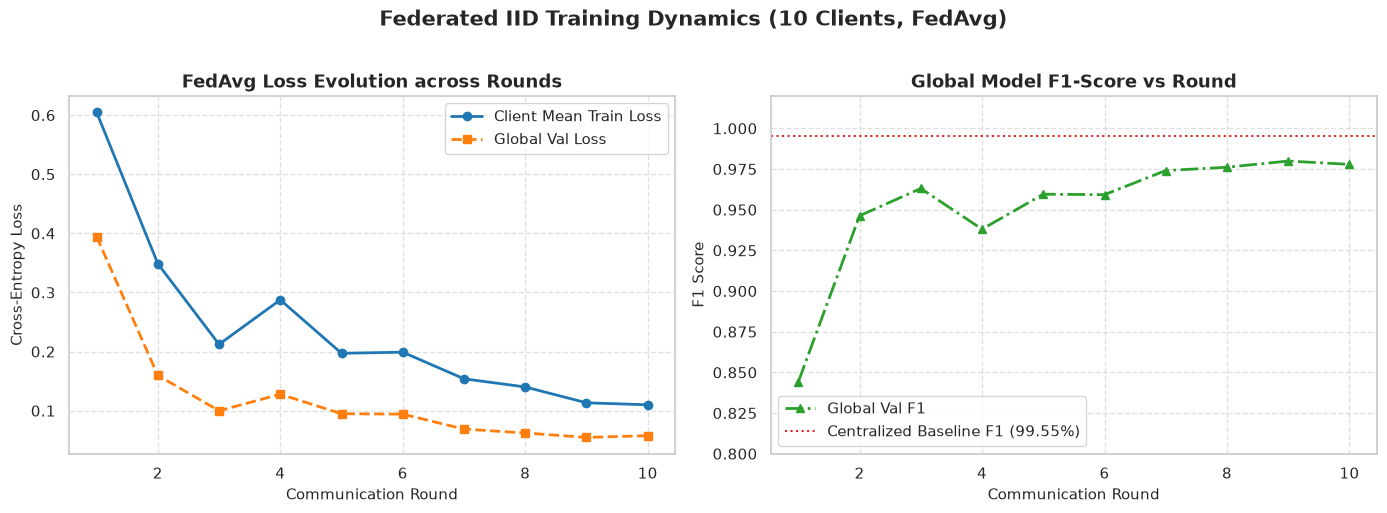

Saved learning curve figure: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\figures\federated_iid_learning_curve.png


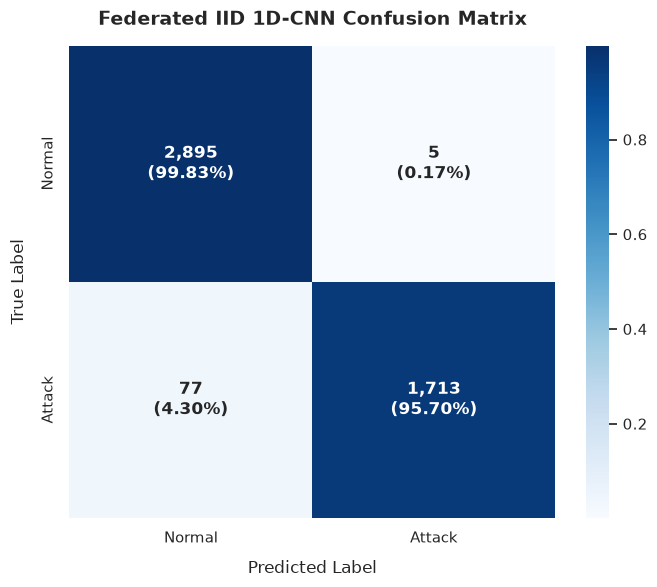

Saved confusion matrix figure: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\figures\federated_iid_confusion_matrix.png


In [8]:
# 7. Visualization: Federated Learning Curves & Test Confusion Matrix
history = server.history
rounds = history["round"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(rounds, history["train_loss"], "o-", label="Client Mean Train Loss", color="#1f77b4", linewidth=2)
ax1.plot(rounds, history["val_loss"], "s--", label="Global Val Loss", color="#ff7f0e", linewidth=2)
ax1.set_title("FedAvg Loss Evolution across Rounds", fontsize=13, fontweight="bold")
ax1.set_xlabel("Communication Round", fontsize=11)
ax1.set_ylabel("Cross-Entropy Loss", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(fontsize=11)

# F1 curve
ax2.plot(rounds, history["val_f1"], "^-.", label="Global Val F1", color="#2ca02c", linewidth=2)
ax2.axhline(cent_metrics["f1_score"], color="#d62728", linestyle=":", linewidth=1.5, label=f"Centralized Baseline F1 ({cent_metrics['f1_score']*100:.2f}%)")
ax2.set_title("Global Model F1-Score vs Round", fontsize=13, fontweight="bold")
ax2.set_xlabel("Communication Round", fontsize=11)
ax2.set_ylabel("F1 Score", fontsize=11)
ax2.set_ylim([0.80, 1.02])
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(fontsize=11)

plt.suptitle("Federated IID Training Dynamics (10 Clients, FedAvg)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()

learning_curve_path = RESULTS_FIGURES / "federated_iid_learning_curve.png"
plt.savefig(learning_curve_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved learning curve figure: {learning_curve_path}")

# Plot confusion matrix
cm_fig_path = RESULTS_FIGURES / "federated_iid_confusion_matrix.png"
plot_confusion_matrix(test_metrics["confusion_matrix"], class_names=["Normal", "Attack"], save_path=cm_fig_path, title="Federated IID 1D-CNN Confusion Matrix")
plt.show()
print(f"Saved confusion matrix figure: {cm_fig_path}")


In [9]:
# 8. Save Model Checkpoint & Metric Artifacts
checkpoint_path = RESULTS_MODELS / "federated_iid_fedavg_best.pt"
checkpoint_payload = {
    "model_state_dict": server.best_model_state,
    "model_config": fed_config["model"],
    "federated_config": fed_config["federated"],
    "history": server.history,
    "best_round": best_round,
    "best_validation_f1": best_val_f1,
    "seed": SEED,
    "test_metrics": test_metrics,
}
torch.save(checkpoint_payload, checkpoint_path)
print(f"Saved best federated model checkpoint: {checkpoint_path}")

# Save standard JSON results report
results_json_path = RESULTS_METRICS / "federated_iid_fedavg.json"
json_payload = {
    "experiment_name": "federated_iid_fedavg",
    "seed": SEED,
    "federated_setup": {
        "num_clients": NUM_CLIENTS,
        "distribution": "IID_stratified",
        "aggregation": "FedAvg",
        "rounds": NUM_ROUNDS,
        "local_epochs": LOCAL_EPOCHS,
        "batch_size": fed_config["client"]["batch_size"],
        "learning_rate": fed_config["client"]["learning_rate"],
    },
    "model_parameters": param_info,
    "communication": comm_info,
    "best_round": best_round,
    "best_validation_f1": round(best_val_f1, 6),
    "total_training_time_seconds": total_time,
    "client_distribution": partition_summary["clients"],
    "test_metrics": test_metrics,
    "centralized_comparison": {
        "centralized_accuracy": cent_metrics["accuracy"],
        "centralized_f1": cent_metrics["f1_score"],
        "federated_accuracy": test_metrics["accuracy"],
        "federated_f1": test_metrics["f1_score"],
    },
}

with open(results_json_path, "w", encoding="utf-8") as f:
    json.dump(json_payload, f, indent=2)
print(f"Saved federated metrics JSON: {results_json_path}")


Saved best federated model checkpoint: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\models\federated_iid_fedavg_best.pt
Saved federated metrics JSON: C:\Users\Kratik\IIIT Academics\Hustle\Major_Project_CAN_IDS\results\metrics\federated_iid_fedavg.json


## 🔬 Scientific Findings & Key Takeaways

### 1. What This Experiment Demonstrates:
1. **Decentralized Convergence:** Under an IID distribution, FedAvg with 10 clients successfully converges within 10 rounds, tracking the centralized baseline's detection accuracy without centralizing raw CAN message streams.
2. **GroupNorm Stability:** Replacing `BatchNorm1d` with `GroupNorm` enables seamless parameter aggregation without running mean or variance distribution mismatches.
3. **Extremely Low Communication Overhead:** With only 40,610 parameters (~158.63 KB per client state dict), the total communication exchange per client per round is $<160$ KB, making it fully compatible with bandwidth-constrained automotive telematics and V2X channels.

### 2. What This Experiment Does NOT Demonstrate:
1. **Non-IID Robustness:** In real-world vehicular fleets, different vehicles have drastically different traffic profiles (e.g., city driving vs highway, varying ECU firmware). Such statistical heterogeneity causes severe weight divergence that standard FedAvg cannot handle without advanced algorithms (FedProx, SCAFFOLD).
2. **Adversarial Resilience:** In this IID baseline, all 10 clients are benign and honest. If a compromised vehicle injects poison updates or flips labels, FedAvg will aggregate malicious weights directly into the global model.

---

**Next Milestone (Phase 2B):** Introduce controlled Dirichlet Non-IID client distributions ($\alpha \in \{0.1, 0.5, 1.0\}$) to evaluate federated client drift under realistic fleet heterogeneity.
